In [151]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
abdallahwagih_mall_customers_segmentation_path = kagglehub.dataset_download('abdallahwagih/mall-customers-segmentation')

print('Data source import complete.')


Using Colab cache for faster access to the 'mall-customers-segmentation' dataset.
Data source import complete.


In [152]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/mall-customers-segmentation/Mall_Customers.csv


In [153]:
import os

# Load dataset
df = pd.read_csv(os.path.join(abdallahwagih_mall_customers_segmentation_path, 'Mall_Customers.csv'))

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [154]:
df.isnull().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [155]:
df1=df.copy()

In [156]:
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].copy()

In [157]:
X['Spending_Efficiency'] = X['Spending Score (1-100)'] / X['Annual Income (k$)']

In [158]:
X = X.drop(['Spending Score (1-100)', 'Annual Income (k$)'], axis=1)

In [159]:
print(X)

     Age  Spending_Efficiency
0     19             2.600000
1     21             5.400000
2     20             0.375000
3     23             4.812500
4     31             2.352941
..   ...                  ...
195   35             0.658333
196   45             0.222222
197   32             0.587302
198   32             0.131387
199   30             0.605839

[200 rows x 2 columns]


In [160]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

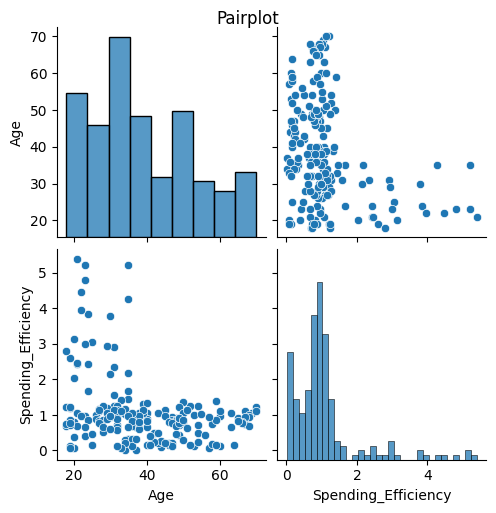

In [161]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(X)
plt.suptitle("Pairplot",y=1.01)
plt.show()

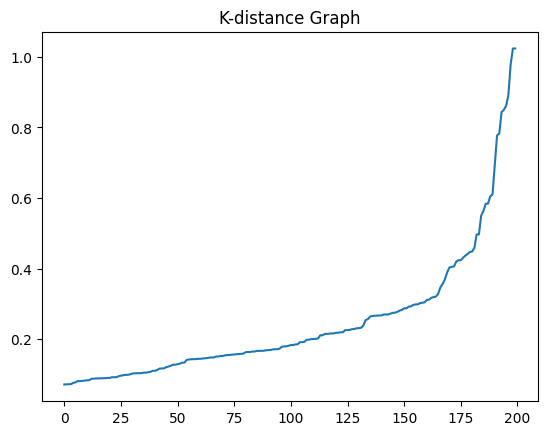

In [162]:
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:,4])

plt.plot(distances)
plt.title("K-distance Graph")
plt.show()

In [198]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

eps_values = np.arange(0.1, 1.1, 0.001)

results = []

for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=5)
    labels = db.fit_predict(X_scaled)

    # Number of clusters (ignore noise)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    # Noise ratio
    noise_ratio = np.sum(labels == -1) / len(labels)

    # Skip bad cases
    if n_clusters < 2 or n_clusters > 7 or noise_ratio >= 0.40:
        continue

    # Remove noise
    mask = labels != -1

    # Silhouette score
    score = silhouette_score(X_scaled[mask], labels[mask])

    if score < 0.3:
        continue

    results.append((eps, n_clusters, score, noise_ratio))

# Show results
for r in results:
    print(f"eps={r[0]:.3f}, clusters={r[1]}, silhouette={r[2]:.3f}, noise={r[3]:.2f}")

eps=0.178, clusters=7, silhouette=0.520, noise=0.39
eps=0.179, clusters=7, silhouette=0.520, noise=0.39
eps=0.180, clusters=7, silhouette=0.520, noise=0.39
eps=0.181, clusters=7, silhouette=0.520, noise=0.39
eps=0.182, clusters=7, silhouette=0.520, noise=0.38
eps=0.183, clusters=7, silhouette=0.520, noise=0.38
eps=0.184, clusters=7, silhouette=0.520, noise=0.38
eps=0.185, clusters=7, silhouette=0.520, noise=0.38
eps=0.186, clusters=7, silhouette=0.520, noise=0.38
eps=0.187, clusters=7, silhouette=0.513, noise=0.36
eps=0.188, clusters=7, silhouette=0.513, noise=0.36
eps=0.189, clusters=7, silhouette=0.513, noise=0.36
eps=0.190, clusters=7, silhouette=0.513, noise=0.36
eps=0.191, clusters=7, silhouette=0.513, noise=0.36
eps=0.192, clusters=7, silhouette=0.514, noise=0.35
eps=0.193, clusters=7, silhouette=0.514, noise=0.35
eps=0.194, clusters=7, silhouette=0.514, noise=0.35
eps=0.195, clusters=7, silhouette=0.514, noise=0.35
eps=0.196, clusters=7, silhouette=0.514, noise=0.35
eps=0.197, c

In [199]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.421, min_samples=5)
labels_db = dbscan.fit_predict(X_scaled)

df['DBSCAN_Cluster'] = labels_db

In [200]:
df['DBSCAN_Cluster'].value_counts()

,count
DBSCAN_Cluster,
1,176
-1,17
0,7


In [201]:
from sklearn.metrics import silhouette_score

labels = df['DBSCAN_Cluster'].values
mask = labels != -1

sil_score = silhouette_score(X_scaled[mask], labels[mask])
print("Silhouette Score:", sil_score)

Silhouette Score: 0.4886605156817829


In [202]:
noise_ratio = np.sum(labels == -1) / len(labels)
print("Noise Ratio:", noise_ratio)

Noise Ratio: 0.085


In [203]:
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print("Number of Clusters:", n_clusters)

Number of Clusters: 2


In [204]:
df[df['DBSCAN_Cluster'] != -1].drop(columns=['Genre', 'CustomerID']).groupby('DBSCAN_Cluster').mean()

,Age,Annual Income (k$),Spending Score (1-100)
DBSCAN_Cluster,,,
0,20.857143,28.428571,75.714286
1,40.704545,65.420455,46.676136


In [205]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


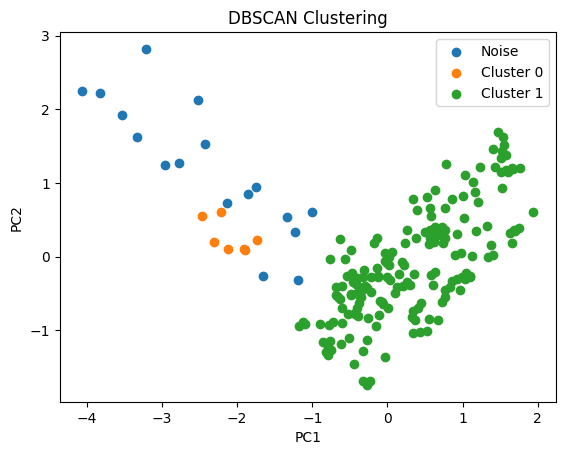

In [206]:
# Get unique cluster labels including noise (-1)
unique_clusters = sorted(df['DBSCAN_Cluster'].unique())

for cluster_label in unique_clusters:
    # Filter data for the current cluster
    cluster_points = X_pca[df['DBSCAN_Cluster'] == cluster_label]

    # Define label for the legend
    if cluster_label == -1:
        label = "Noise"
    else:
        label = f"Cluster {cluster_label}"

    # Plot points for the current cluster
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=label)

plt.title("DBSCAN Clustering")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend() # Add legend
plt.show()